# Data Quality Audit (Energy Market Parquet Files)
Automated checks for structure, temporal consistency, missingness, plausibility, and merge readiness.


In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
try:
    import missingno as msno
    HAS_MSNO = True
except ImportError:
    HAS_MSNO = False
    print('missingno not installed; skipping missingness plots.')
from pathlib import Path

pd.set_option('display.max_columns', 200)
# Resolve data dir robustly regardless of notebook cwd
_candidates = [
    Path('data'),
    Path('..')/'data',
    Path('energy_trading')/'data',
    Path('..')/'energy_trading'/'data'
]
DATA_DIR = next((c.resolve() for c in _candidates if c.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError('Could not locate data directory from candidates')
FILES = [
    'regelleistung.parquet',
    'co2_price.parquet',
    'commodities.parquet',
    'smard.parquet',
    'netztransparenz.parquet',
    'day_ahead_prices.parquet',
    'entsoe.parquet',
]


In [2]:
def ensure_timestamp(df):
    ts_col = None
    for c in df.columns:
        if 'timestamp' in c.lower():
            ts_col = c
            break
    if ts_col is None and isinstance(df.index, pd.DatetimeIndex):
        ts = pd.Series(df.index)
    elif ts_col:
        ts = pd.to_datetime(df[ts_col], errors='coerce')
    else:
        ts = pd.to_datetime(pd.Series([], dtype='datetime64[ns]'))
    ts = ts.dt.tz_convert('UTC') if ts.dt.tz is not None else ts.dt.tz_localize('UTC')
    if ts_col:
        df = df.drop(columns=[ts_col])
    elif isinstance(df.index, pd.DatetimeIndex):
        df = df.reset_index(drop=True)
    if 'timestamp' in df.columns:
        df = df.drop(columns=['timestamp'])
    df.insert(0, 'timestamp', ts)
    return df


In [3]:
def realism_flags(df):
    flags = {}
    for c in df.columns:
        if c=='timestamp':
            continue
        s = df[c]
        if not pd.api.types.is_numeric_dtype(s):
            continue
        if 'price' in c.lower():
            flags[c] = (~s.between(-500, 3000)).sum()
        elif 'co2' in c.lower() or 'gas' in c.lower():
            flags[c] = (s <= 0).sum()
        elif 'mw' in c.lower():
            flags[c] = (s < 0).sum()
        elif 'mwh' in c.lower() or 'balance' in c.lower():
            flags[c] = (s < -1e-9).sum()
    return flags


In [4]:
def load_parquet(name):
    path = DATA_DIR / name
    df = pd.read_parquet(path)
    return df

def ensure_timestamp(df):
    ts_col = None
    for c in df.columns:
        if 'timestamp' in c.lower():
            ts_col = c
            break
    if ts_col is None and isinstance(df.index, pd.DatetimeIndex):
        ts = pd.Series(df.index)
    elif ts_col:
        ts = pd.to_datetime(df[ts_col], errors='coerce')
    else:
        ts = pd.to_datetime(pd.Series([], dtype='datetime64[ns]'))
    ts = ts.dt.tz_convert('UTC') if ts.dt.tz is not None else ts.dt.tz_localize('UTC')
    if ts_col:
        df = df.drop(columns=[ts_col])
    elif isinstance(df.index, pd.DatetimeIndex):
        df = df.reset_index(drop=True)
    if 'timestamp' in df.columns:
        df = df.drop(columns=['timestamp'])
    df.insert(0, 'timestamp', ts)
    return df

def schema_inventory(df):
    ts = df['timestamp']
    return {
        'ts_dtype': str(ts.dtype),
        'tz': str(ts.dt.tz),
        'numeric_all_float64': all(str(t)=='float64' for c,t in df.dtypes.items() if c!='timestamp'),
        'columns': list(df.columns)
    }

def time_coverage(df):
    ts = df['timestamp']
    return ts.min(), ts.max()

def avg_step(df):
    ts = df['timestamp'].sort_values()
    if len(ts) < 2:
        return pd.NaT
    return ts.diff().dropna().mode().iloc[0]

def gaps_and_dupes(df):
    ts = df['timestamp'].sort_values()
    dupes = ts.duplicated().sum()
    if len(ts)==0: return dupes, None
    full = pd.date_range(ts.min(), ts.max(), freq='1h', tz='UTC')
    missing = len(full.difference(ts))
    return dupes, missing

def nan_percent(df):
    return (df.isna().mean()*100).sort_values(ascending=False)

def zero_counts(df):
    zeros = {}
    for c in df.columns:
        if c=='timestamp': continue
        zeros[c] = (df[c]==0).sum()
    return zeros

def realism_flags(df):
    flags = {}
    for c in df.columns:
        if c=='timestamp':
            continue
        s = df[c]
        if not pd.api.types.is_numeric_dtype(s):
            continue
        if 'price' in c.lower():
            flags[c] = (~s.between(-500, 3000)).sum()
        elif 'co2' in c.lower() or 'gas' in c.lower():
            flags[c] = (s <= 0).sum()
        elif 'mw' in c.lower():
            flags[c] = (s < 0).sum()
        elif 'mwh' in c.lower() or 'balance' in c.lower():
            flags[c] = (s < -1e-9).sum()
    return flags


In [5]:
results = {}
coverage = []
granularity = []
gaps_dupes = []
nan_summaries = {}
zero_summaries = {}
realism = {}
describes = {}
dfs = {}
for fname in FILES:
    df = load_parquet(fname)
    df = ensure_timestamp(df)
    dfs[fname] = df
    results[fname] = schema_inventory(df)
    s,e = time_coverage(df); coverage.append((fname,s,e))
    granularity.append((fname, avg_step(df)))
    dup, miss = gaps_and_dupes(df); gaps_dupes.append((fname, dup, miss))
    nan_summaries[fname] = nan_percent(df)
    zero_summaries[fname] = zero_counts(df)
    realism[fname] = realism_flags(df)
    describes[fname] = df.describe(include='all')
print('Schema check done')


Schema check done


## Schema & Columns

In [6]:
schema_df = pd.DataFrame(results).T
schema_df


,ts_dtype,tz,numeric_all_float64,columns
regelleistung.parquet,"datetime64[us, UTC]",UTC,False,"[timestamp, timestamp_cet, afrr_capacity_offer..."
co2_price.parquet,"datetime64[ms, UTC]",UTC,False,"[timestamp, timestamp_cet, co2_price_eua, ticker]"
commodities.parquet,"datetime64[ms, UTC]",UTC,False,"[timestamp, timestamp_cet, gas_price_ttf, coal..."
smard.parquet,"datetime64[ms, UTC]",UTC,False,"[timestamp, timestamp_cet, load_actual, timest..."
netztransparenz.parquet,"datetime64[us, UTC]",UTC,True,"[timestamp, NRV_balance, reBAP_shortage_surplu..."
day_ahead_prices.parquet,"datetime64[us, UTC]",UTC,False,"[timestamp, timestamp_cet, da_price_DE-LU, da_..."
entsoe.parquet,"datetime64[us, UTC]",UTC,False,"[timestamp, timestamp_cet, year, month, day, s..."


## Time coverage (Gantt) & Granularity

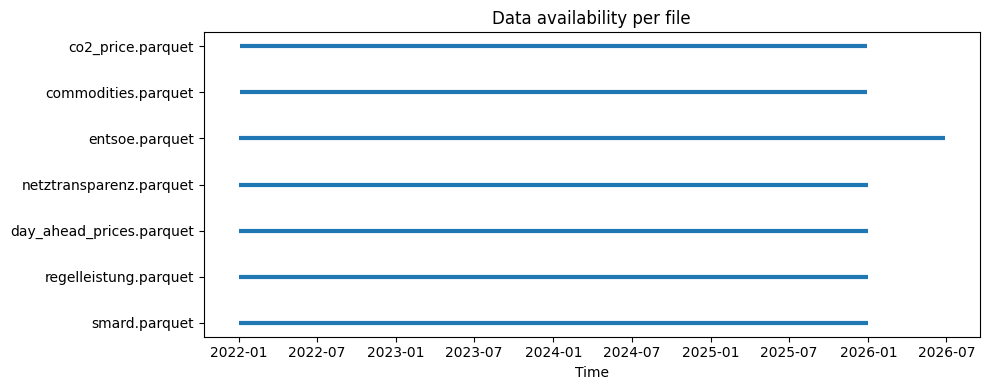

,avg_step
file,
regelleistung.parquet,0 days 00:15:00
co2_price.parquet,1 days 00:00:00
commodities.parquet,0 days 01:00:00
smard.parquet,0 days 01:00:00
netztransparenz.parquet,0 days 01:00:00
day_ahead_prices.parquet,0 days 01:00:00
entsoe.parquet,0 days 00:15:00


In [7]:
cov_df = pd.DataFrame(coverage, columns=['file','start','end']).sort_values('start')
plt.figure(figsize=(10,4))
for i,row in cov_df.iterrows():
    plt.hlines(y=row['file'], xmin=row['start'], xmax=row['end'], colors='tab:blue', linewidth=3)
plt.title('Data availability per file')
plt.xlabel('Time')
plt.tight_layout()
plt.show()
gran_df = pd.DataFrame(granularity, columns=['file','avg_step']).set_index('file')
gran_df


## Gaps & Duplicates

In [8]:
gaps_df = pd.DataFrame(gaps_dupes, columns=['file','duplicates','missing_hours'])
gaps_df


,file,duplicates,missing_hours
0,regelleistung.parquet,0,0
1,co2_price.parquet,0,33929
2,commodities.parquet,0,0
3,smard.parquet,0,16
4,netztransparenz.parquet,0,0
5,day_ahead_prices.parquet,0,0
6,entsoe.parquet,0,1089


## Missingness (NaNs)

Missingness for regelleistung.parquet


,afrr_capacity_offered_mw_neg,afrr_capacity_offered_mw_pos,afrr_capacity_price_neg,afrr_capacity_price_pos,timestamp,timestamp_cet,afrr_activation_avg_price_neg,afrr_activation_avg_price_pos,afrr_activation_price_neg,afrr_activation_price_pos,afrr_activation_offered_mw_neg,afrr_activation_offered_mw_pos
percent_nan,0.216745,0.216745,0.216745,0.216745,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


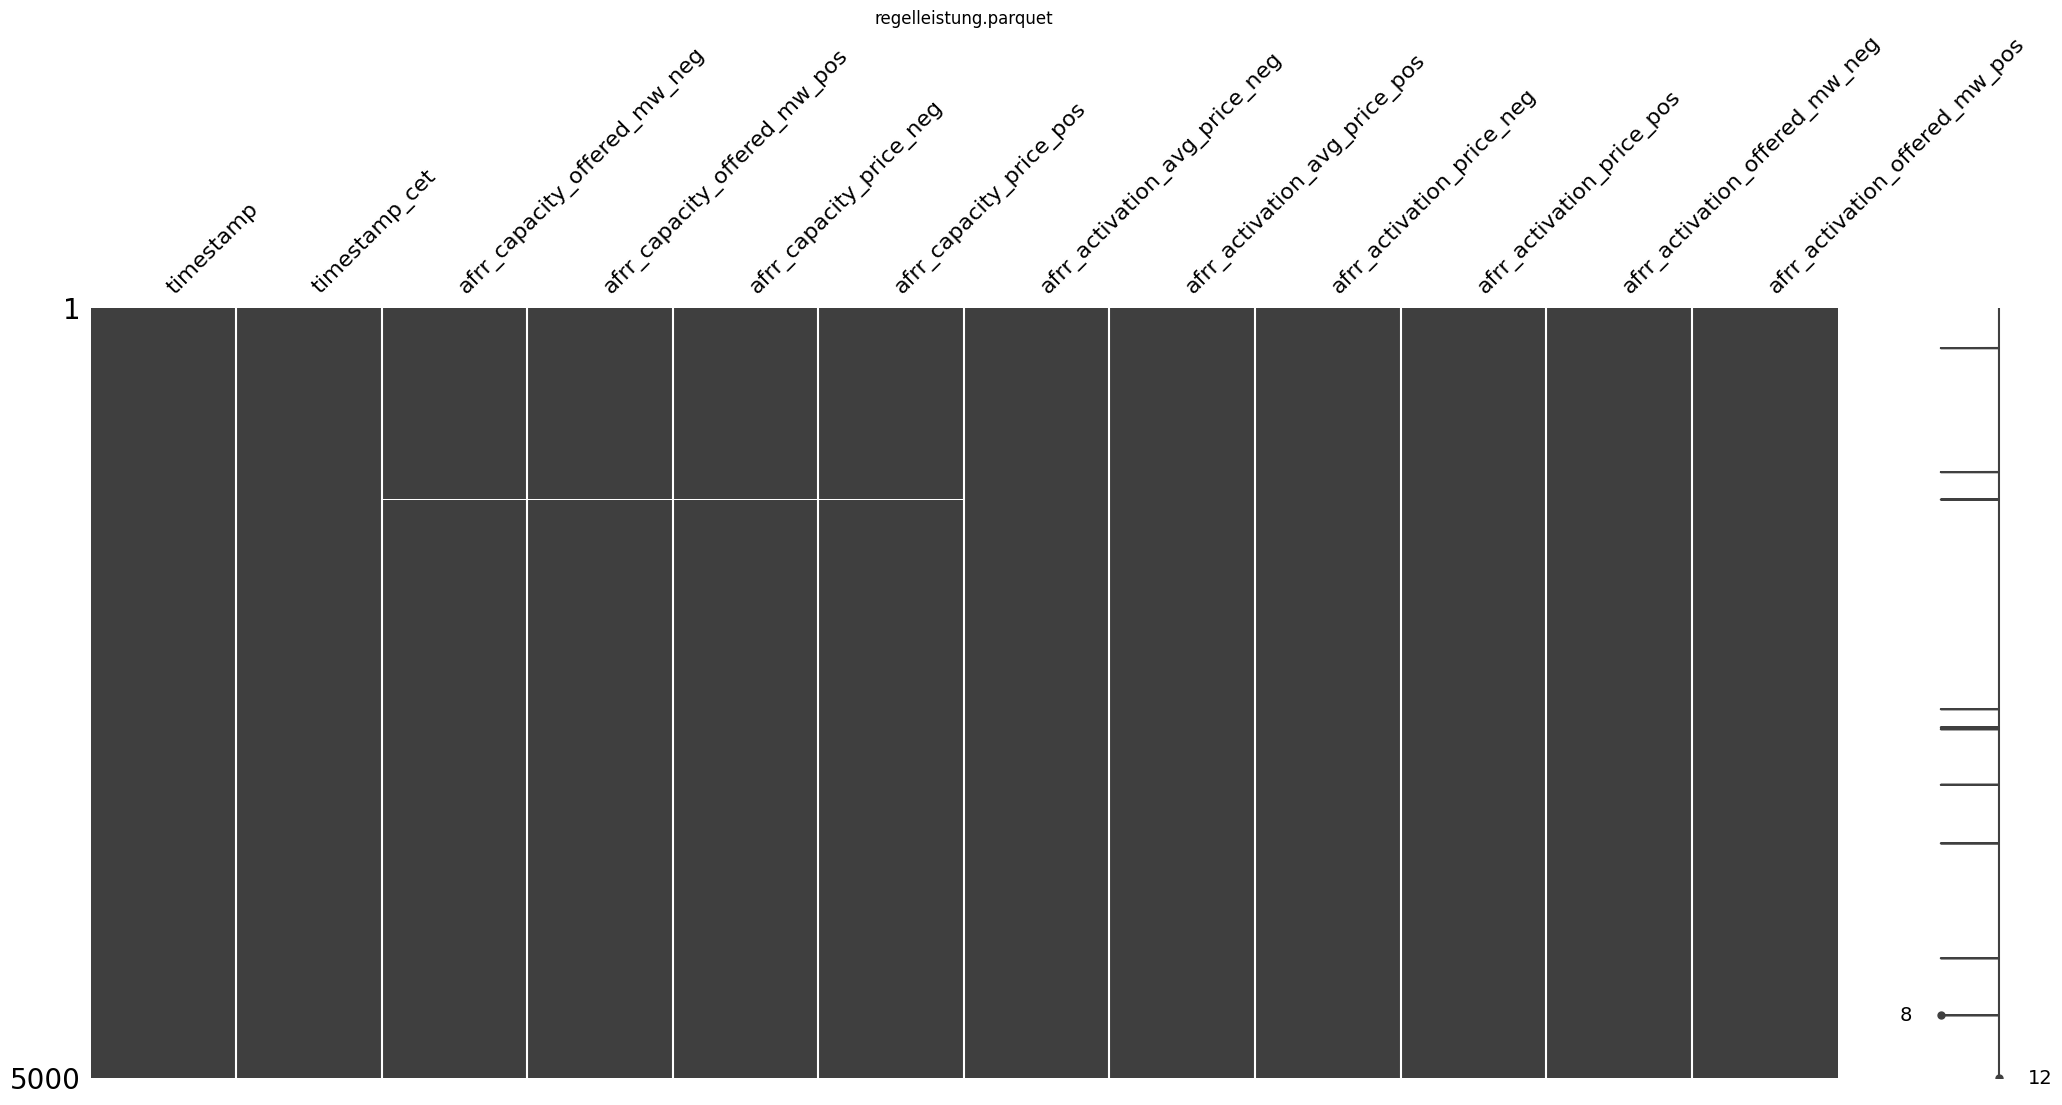

Missingness for co2_price.parquet


,timestamp,timestamp_cet,co2_price_eua,ticker
percent_nan,0.0,0.0,0.0,0.0


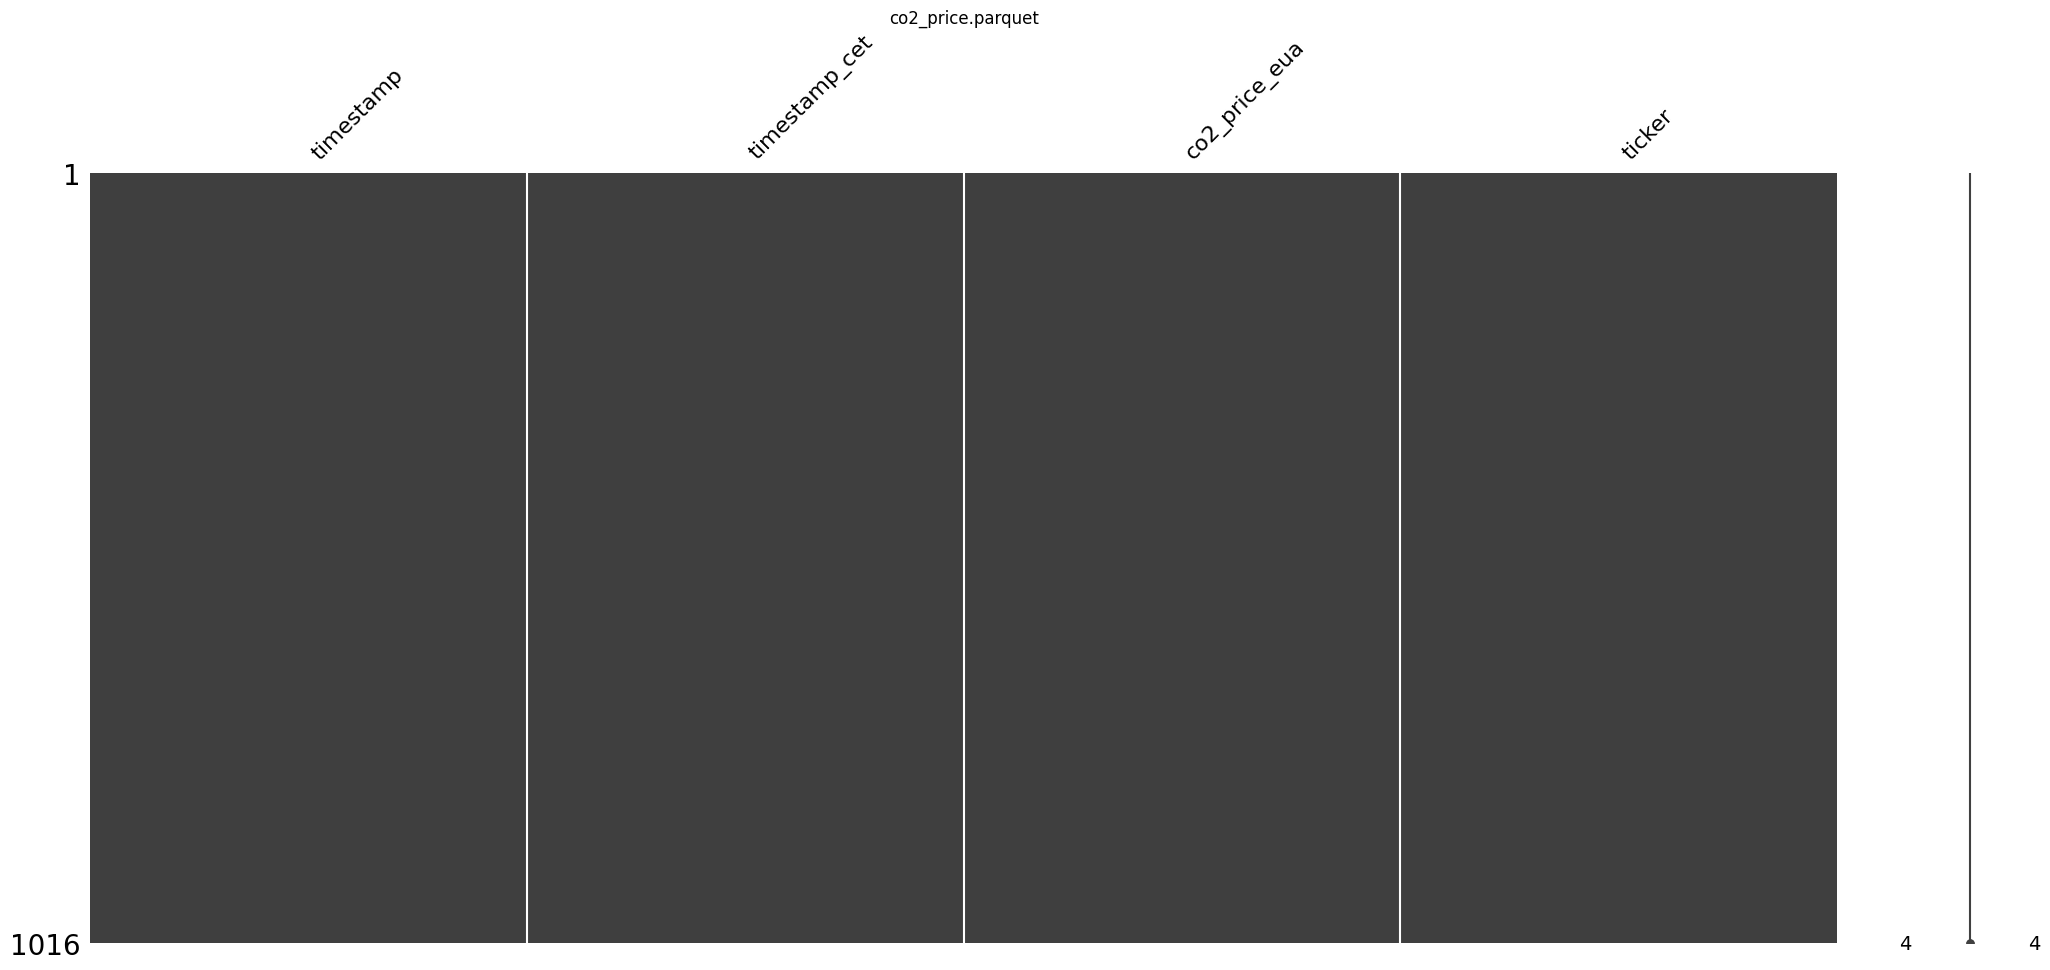

Missingness for commodities.parquet


,coal_price_api2,co2_price_eua,gas_price_ttf,timestamp,timestamp_cet
percent_nan,1.924562,1.715805,1.647173,0.0,0.0


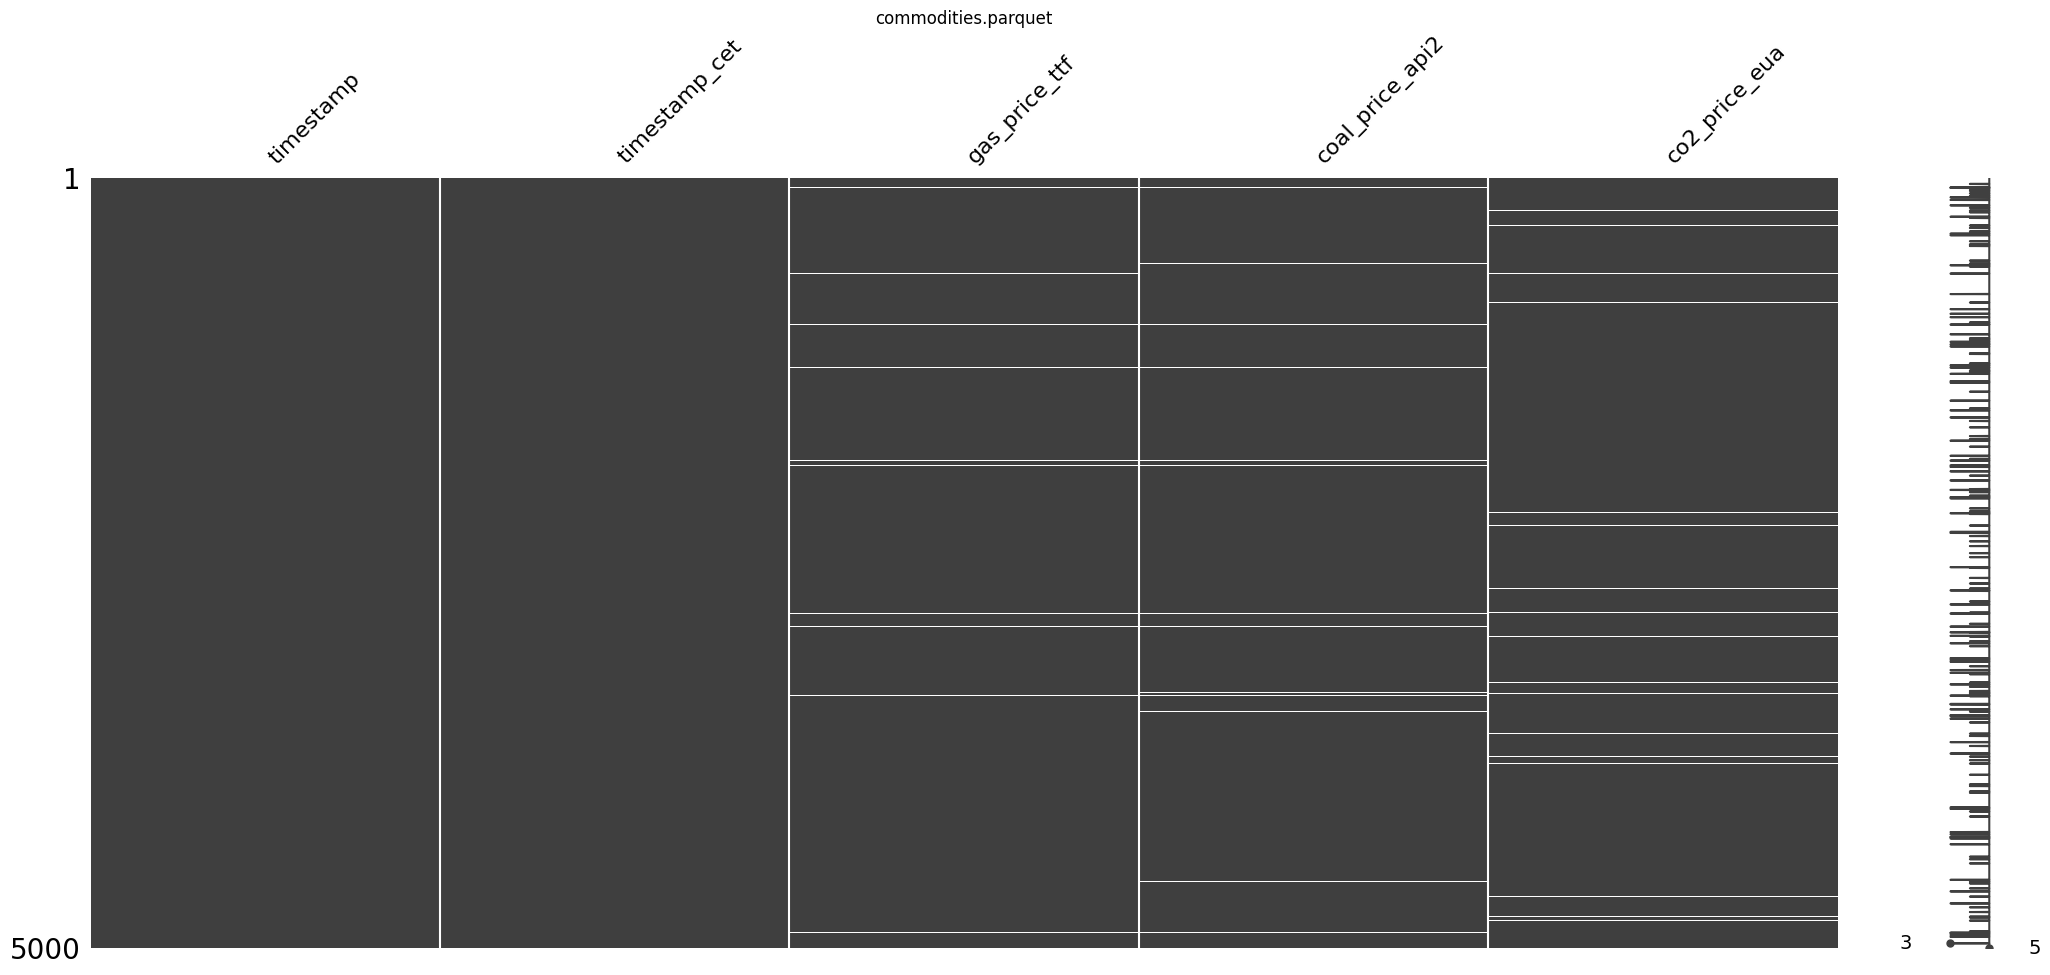

Missingness for smard.parquet


,wind_forecast_de,solar_forecast,wind_onshore_forecast,timestamp_cet,da_price_eur,timestamp_da_price_eur,timestamp_solar_forecast,wind_offshore_forecast,timestamp_wind_offshore_forecast,timestamp_wind_onshore_forecast,timestamp,timestamp_solar_actual,wind_offshore_actual,timestamp_wind_offshore_actual,wind_onshore_actual,timestamp_wind_onshore_actual,residual_load_actual,timestamp_residual_load_actual,load_actual,solar_actual
percent_nan,0.008565,0.008565,0.008565,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


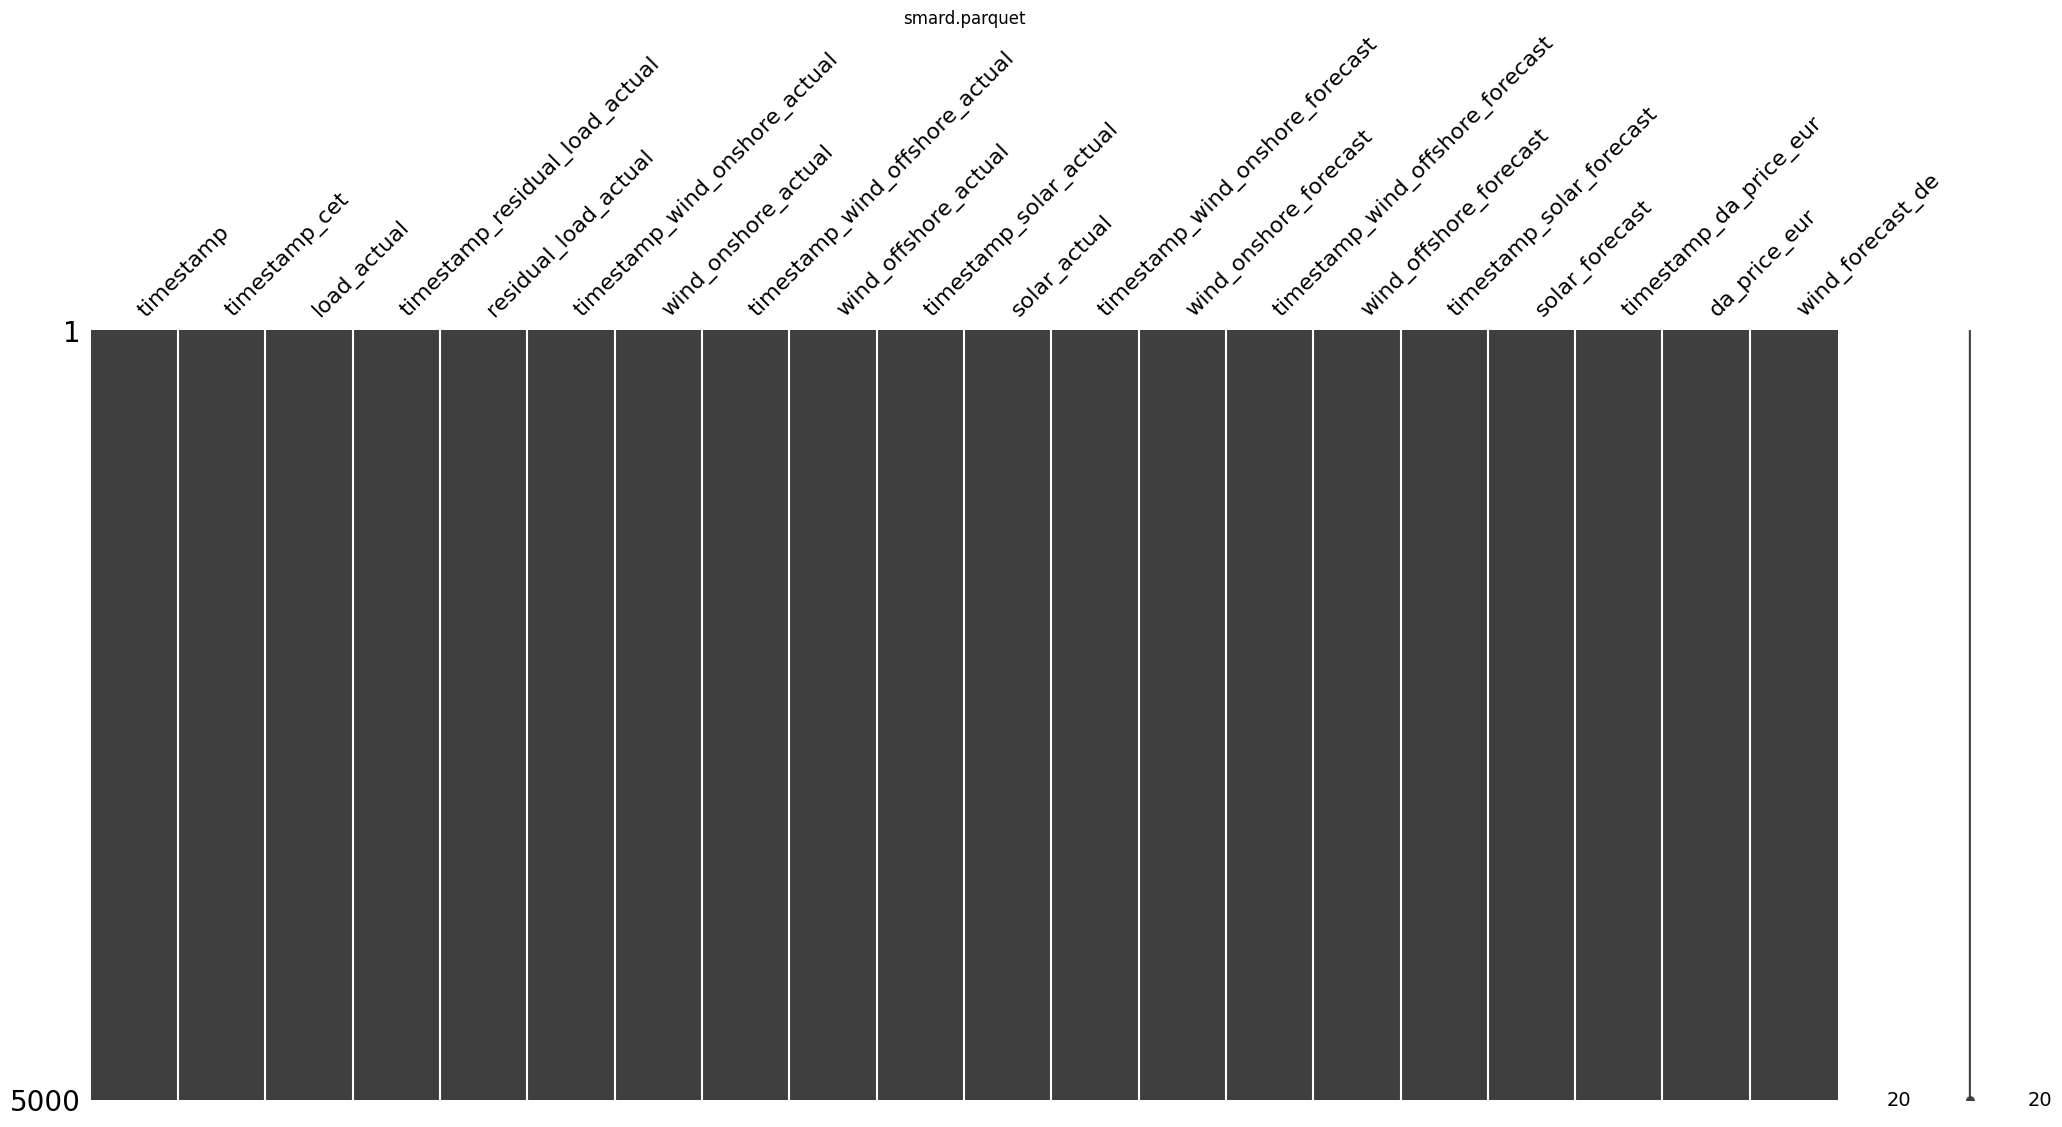

Missingness for netztransparenz.parquet


,activated_volume_pos_mw,activated_volume_neg_mw,NRV_balance,nrv_imbalance,timestamp,reBAP_shortage_surplus
percent_nan,8.418891,8.418891,6.294205,6.294205,0.0,0.0


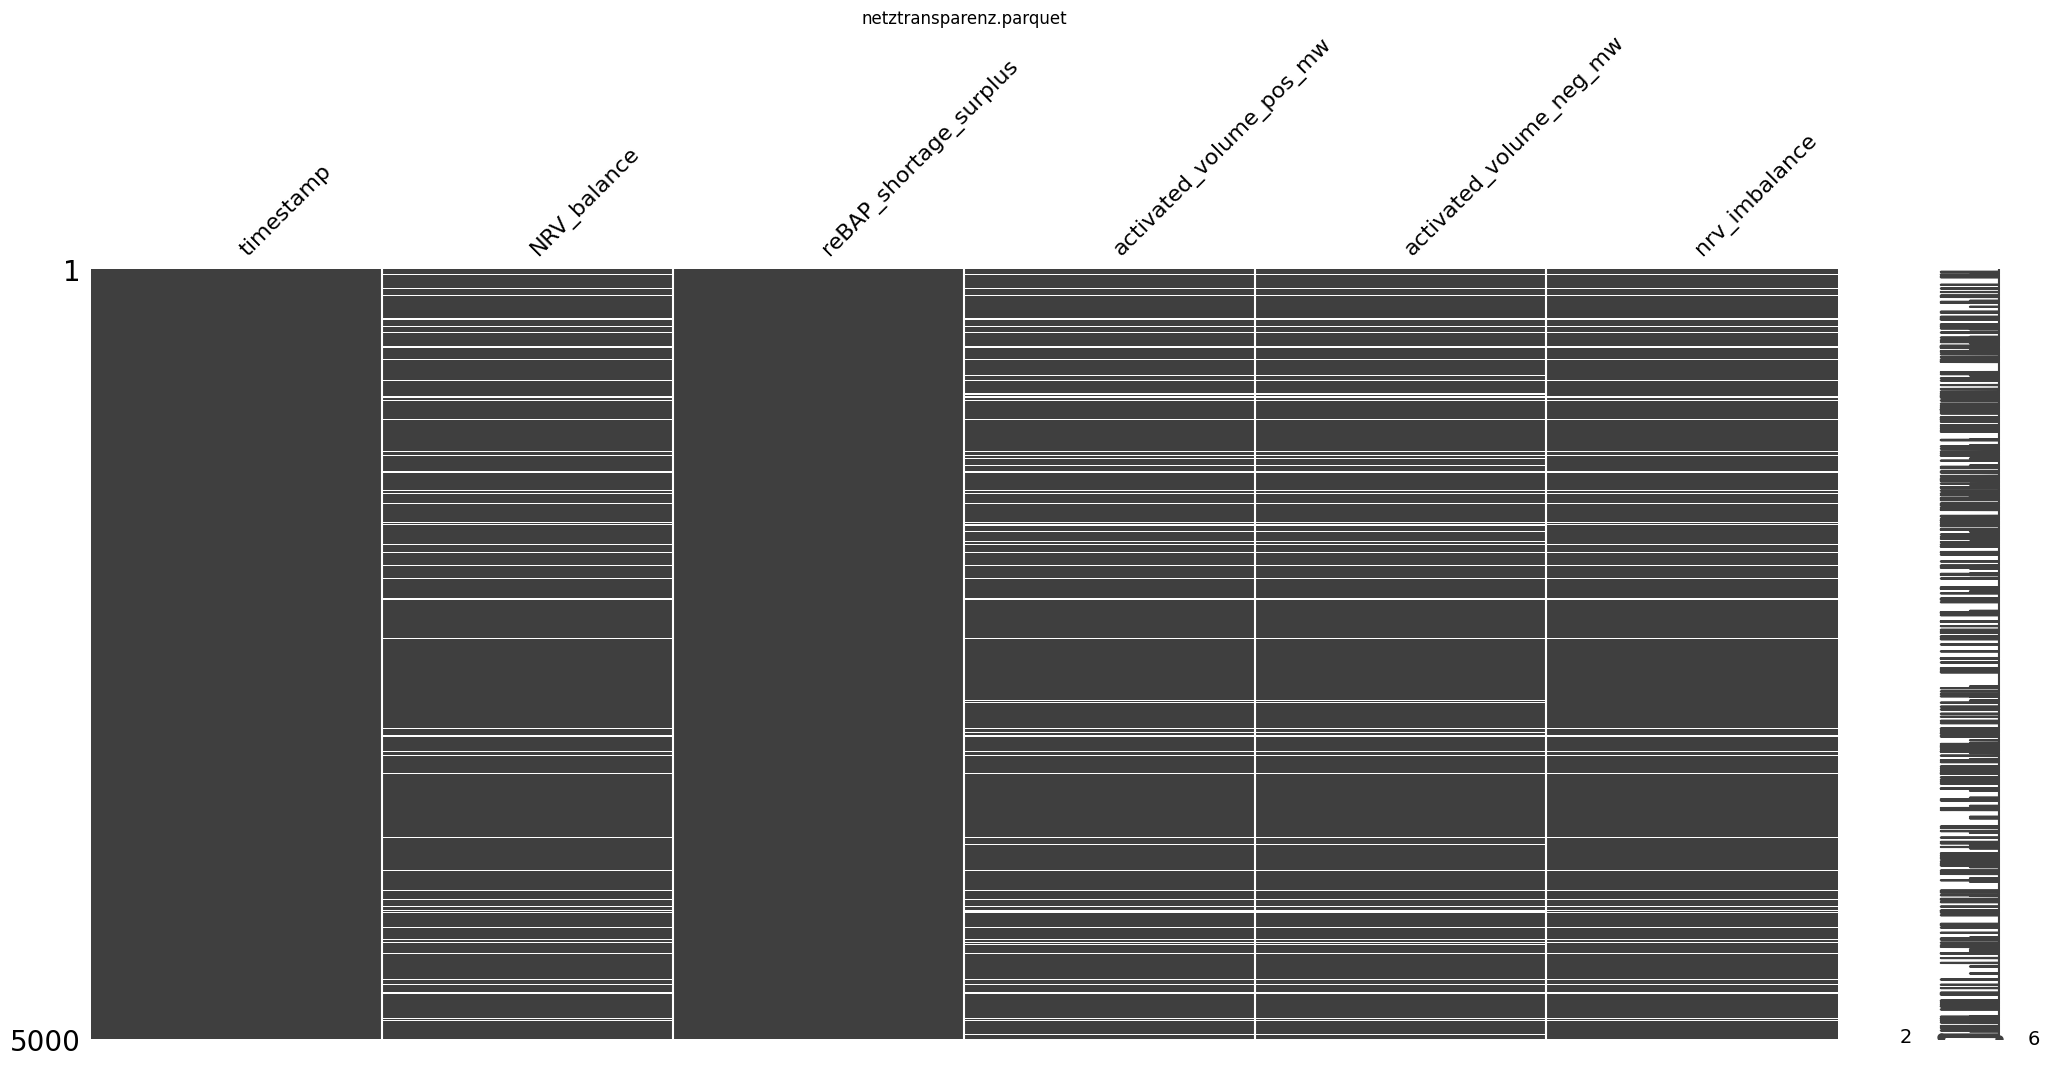

Missingness for day_ahead_prices.parquet


,da_price_NO2,da_price_BE,timestamp,timestamp_cet,da_price_DE-LU,da_price_AT,da_price_CH,da_price_CZ,da_price_DK1,da_price_DK2,da_price_FR,da_price_NL,da_price_PL,da_price_SE4
percent_nan,15.055327,0.068446,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


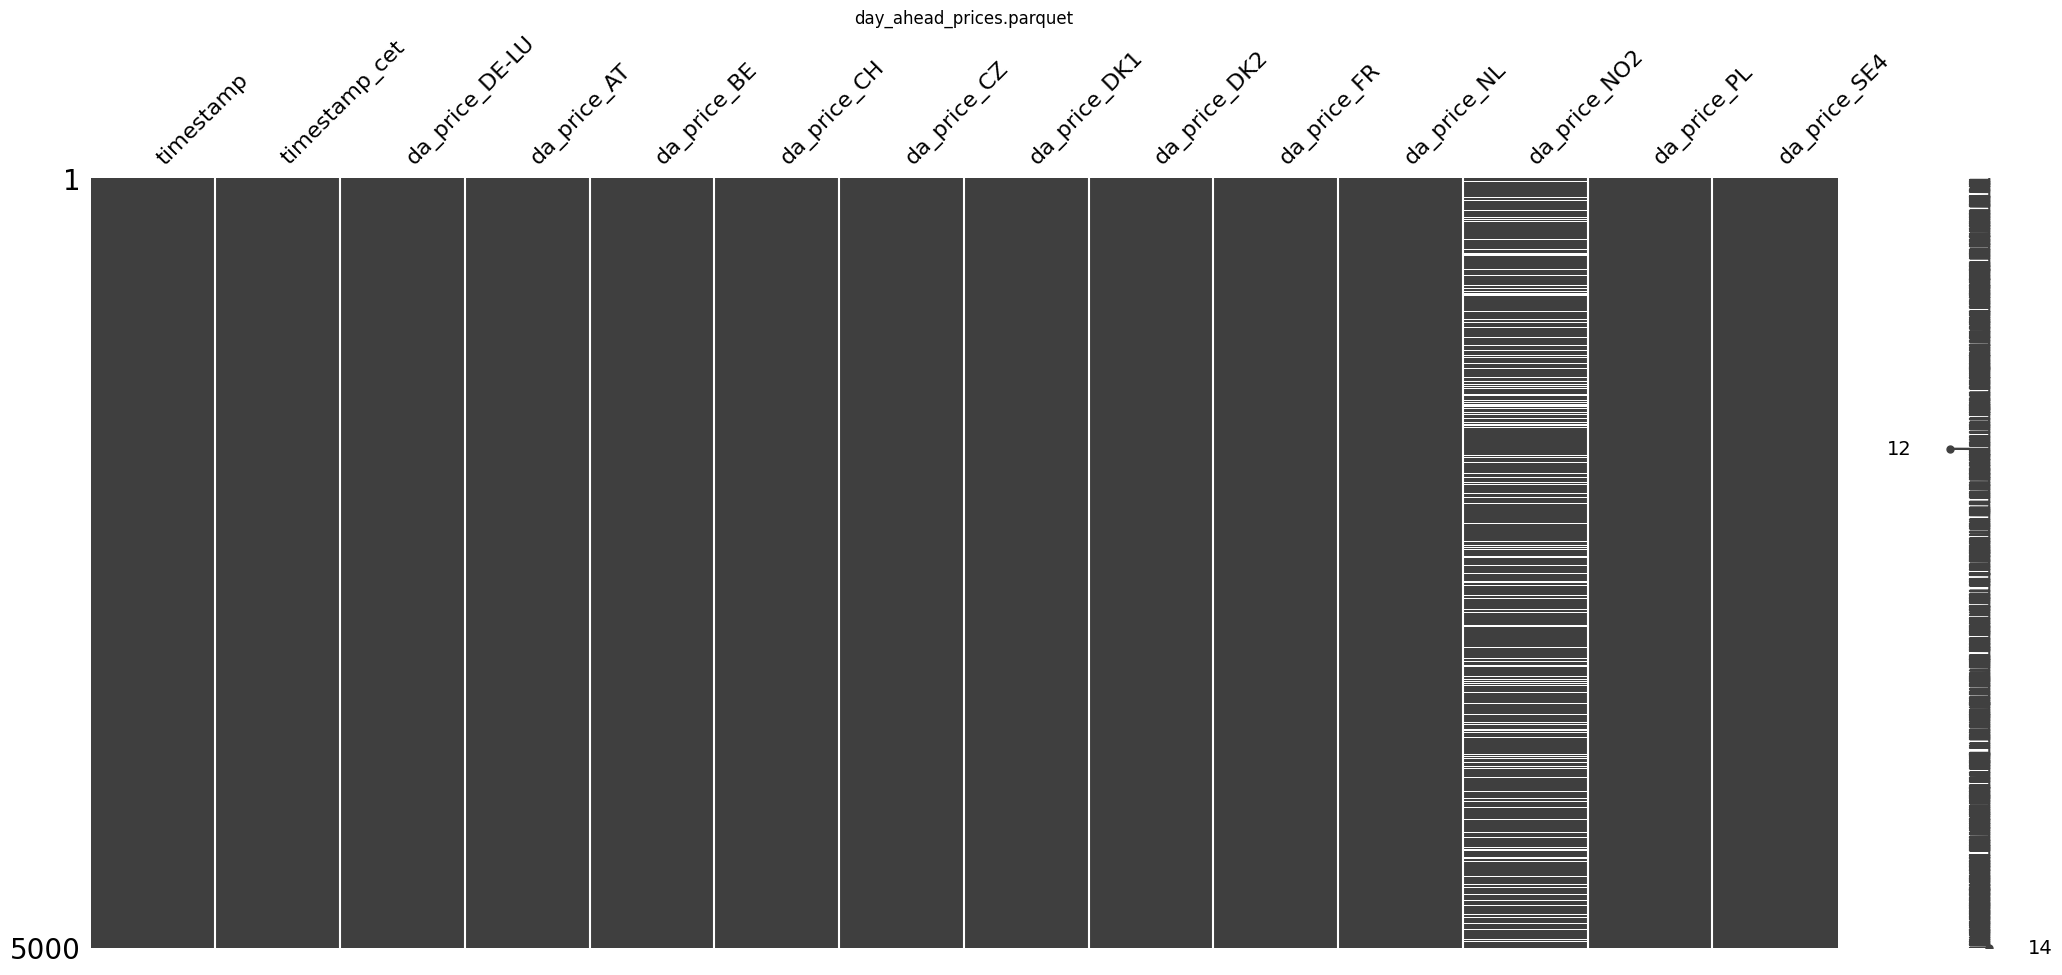

Missingness for entsoe.parquet


,flow_export_SE4,flow_export_NO2,flow_import_PL,flow_export_FR,flow_export_DK1,flow_export_DK2,flow_export_BE,flow_import_CH,flow_import_DK1,flow_import_FR,flow_import_NL,flow_import_NO2,flow_export_NL,flow_import_SE4,flow_export_CH,flow_import_CZ,flow_export_CZ,flow_import_DK2,flow_import_BE,flow_export_PL,flow_import_AT,GEN_THERMAL,U_THERMAL,GEN_FOSSIL_BROWN_COAL_LIGNITE,GEN_FOSSIL_HARD_COAL,GEN_FOSSIL_GAS,GEN_NUCLEAR,flow_export_AT,system_load_forecast,timestamp_cet,day,month,year,timestamp
percent_nan,96.574345,93.885294,93.14721,89.860592,88.207669,86.738158,84.996487,81.629257,79.59398,79.478608,79.021558,78.943165,78.912843,78.710942,77.725104,77.019561,76.774027,76.56473,75.243871,74.730614,74.076101,74.068705,74.068705,74.068705,74.068705,74.068705,74.068705,74.068705,4.36564,0.0,0.0,0.0,0.0,0.0


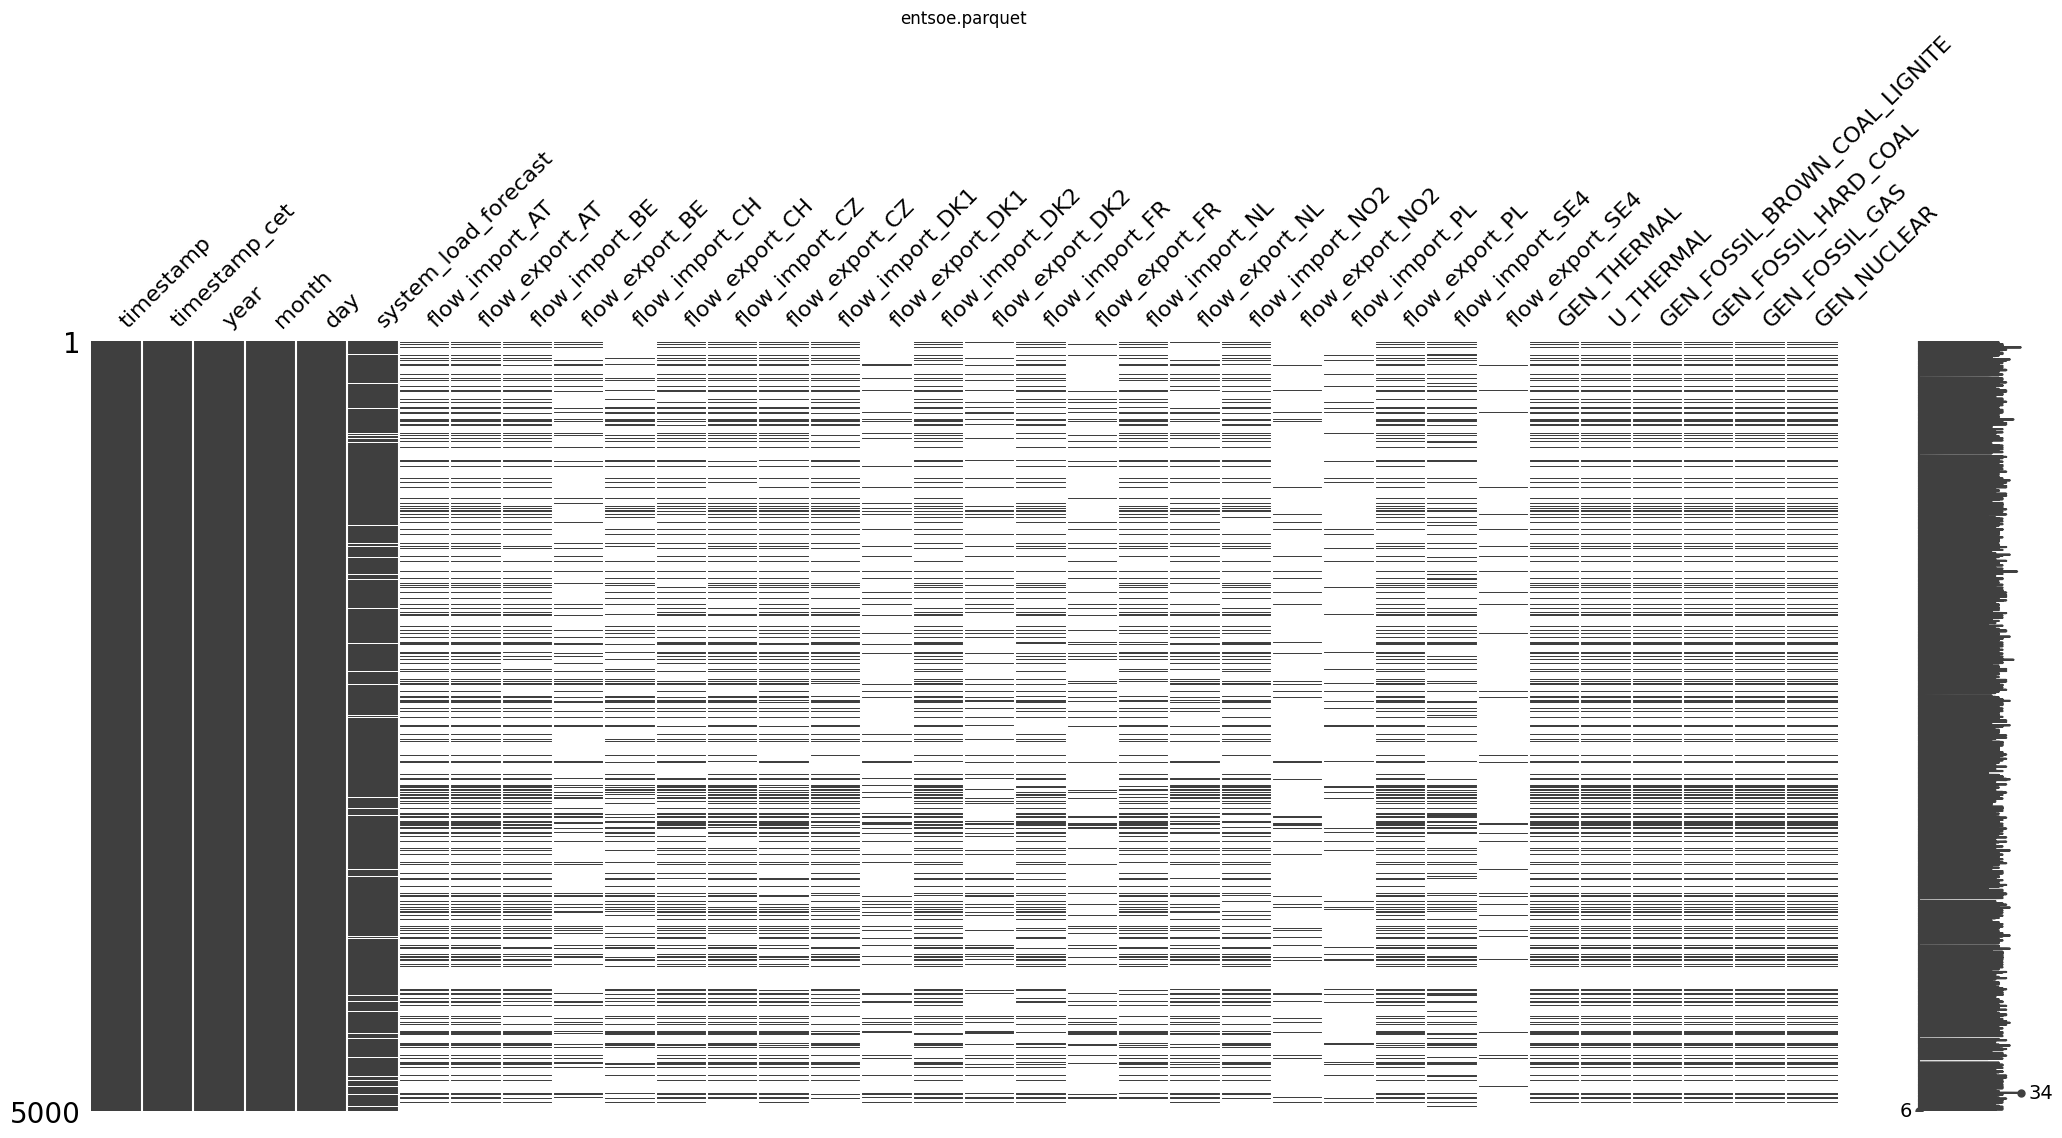

In [9]:
for fname, df in dfs.items():
    print(f'Missingness for {fname}')
    display(nan_summaries[fname].to_frame('percent_nan').T)
    if HAS_MSNO:
        msno.matrix(df.sample(min(len(df), 5000)))
        plt.title(fname)
        plt.show()
    else:
        print('missingno not available, plot skipped')


## Zero-value check

In [10]:
zero_df = {k: pd.Series(v) for k,v in zero_summaries.items()}
zero_df = pd.DataFrame(zero_df)
zero_df


,regelleistung.parquet,co2_price.parquet,commodities.parquet,smard.parquet,netztransparenz.parquet,day_ahead_prices.parquet,entsoe.parquet
GEN_FOSSIL_BROWN_COAL_LIGNITE,NaN,NaN,NaN,NaN,NaN,NaN,0.0
GEN_FOSSIL_GAS,NaN,NaN,NaN,NaN,NaN,NaN,0.0
GEN_FOSSIL_HARD_COAL,NaN,NaN,NaN,NaN,NaN,NaN,0.0
GEN_NUCLEAR,NaN,NaN,NaN,NaN,NaN,NaN,23785.0
GEN_THERMAL,NaN,NaN,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...
wind_offshore_actual,NaN,NaN,NaN,24.0,NaN,NaN,NaN
wind_offshore_forecast,NaN,NaN,NaN,0.0,NaN,NaN,NaN
wind_onshore_actual,NaN,NaN,NaN,0.0,NaN,NaN,NaN
wind_onshore_forecast,NaN,NaN,NaN,0.0,NaN,NaN,NaN


## Realism flags

In [11]:
realism_df = {k: pd.Series(v) for k,v in realism.items()}
realism_df = pd.DataFrame(realism_df)
realism_df


,regelleistung.parquet,co2_price.parquet,commodities.parquet,smard.parquet,netztransparenz.parquet,day_ahead_prices.parquet,entsoe.parquet
GEN_FOSSIL_GAS,NaN,NaN,NaN,NaN,NaN,NaN,0.0
NRV_balance,NaN,NaN,NaN,NaN,15770.0,NaN,NaN
activated_volume_neg_mw,NaN,NaN,NaN,NaN,0.0,NaN,NaN
activated_volume_pos_mw,NaN,NaN,NaN,NaN,0.0,NaN,NaN
afrr_activation_avg_price_neg,126370.0,NaN,NaN,NaN,NaN,NaN,NaN
afrr_activation_avg_price_pos,13839.0,NaN,NaN,NaN,NaN,NaN,NaN
afrr_activation_offered_mw_neg,0.0,NaN,NaN,NaN,NaN,NaN,NaN
afrr_activation_offered_mw_pos,0.0,NaN,NaN,NaN,NaN,NaN,NaN
afrr_activation_price_neg,139472.0,NaN,NaN,NaN,NaN,NaN,NaN
afrr_activation_price_pos,135454.0,NaN,NaN,NaN,NaN,NaN,NaN


## Descriptive stats

In [12]:
for fname, desc in describes.items():
    print(f'Describe for {fname}')
    display(desc)


Describe for regelleistung.parquet


,timestamp,timestamp_cet,afrr_capacity_offered_mw_neg,afrr_capacity_offered_mw_pos,afrr_capacity_price_neg,afrr_capacity_price_pos,afrr_activation_avg_price_neg,afrr_activation_avg_price_pos,afrr_activation_price_neg,afrr_activation_price_pos,afrr_activation_offered_mw_neg,afrr_activation_offered_mw_pos
count,140257,140257,139953.000000,139953.000000,139953.000000,139953.000000,140257.000000,140257.000000,140257.000000,140257.000000,140257.000000,140257.000000
mean,2024-01-01 10:45:00+00:00,2024-01-01 10:45:00,3692.658743,4411.685402,10.100410,20.602735,-1364.173244,1886.938606,-15223.317890,19325.815476,2150.497925,2145.843537
min,2021-12-31 22:45:00+00:00,2021-12-31 22:45:00,2152.000000,2473.000000,0.420000,0.660000,-21358.660000,226.480000,-99999.990000,300.830000,0.000000,0.000000
25%,2023-01-01 04:45:00+00:00,2023-01-01 04:45:00,3427.000000,4139.000000,1.780000,8.540000,-1486.660000,987.130000,-15000.000000,15000.000000,1976.000000,2003.000000
50%,2024-01-01 10:45:00+00:00,2024-01-01 10:45:00,3719.000000,4450.000000,3.510000,15.200000,-1136.250000,1403.320000,-15000.000000,15000.000000,2134.000000,2117.000000
75%,2024-12-31 16:45:00+00:00,2024-12-31 16:45:00,3999.000000,4718.000000,8.500000,26.090000,-868.460000,1936.180000,-15000.000000,15000.000000,2304.000000,2263.000000
max,2025-12-31 22:45:00+00:00,2025-12-31 22:45:00,5011.000000,5827.000000,1979.000000,3783.560000,62.000000,35072.190000,-59.400000,99999.990000,3042.000000,4794.000000
std,NaN,NaN,397.155808,436.100715,34.997423,37.799348,1352.106484,2121.092728,12022.653164,19552.747971,225.299911,197.491309


Describe for co2_price.parquet


,timestamp,timestamp_cet,co2_price_eua,ticker
count,1016,1016,1016.000000,1016
unique,NaN,NaN,NaN,2
top,NaN,NaN,NaN,CO2.L
freq,NaN,NaN,NaN,677
mean,2024-01-03 18:55:16.535000+00:00,2024-01-03 18:55:16.535000,52.529715,NaN
min,2022-01-04 00:00:00+00:00,2022-01-04 00:00:00,4.896200,NaN
25%,2023-01-08 06:00:00+00:00,2023-01-08 06:00:00,5.415800,NaN
50%,2024-01-06 12:00:00+00:00,2024-01-06 12:00:00,68.042500,NaN
75%,2025-01-02 06:00:00+00:00,2025-01-02 06:00:00,80.463747,NaN
max,2025-12-30 00:00:00+00:00,2025-12-30 00:00:00,96.415001,NaN


Describe for commodities.parquet


...

,timestamp,NRV_balance,reBAP_shortage_surplus,activated_volume_pos_mw,activated_volume_neg_mw,nrv_imbalance
count,35064,32857.000000,35064.000000,32112.000000,32112.000000,32857.000000
mean,2024-01-01 11:30:00+00:00,23.176336,122.225013,1.727910,2.303869,23.176336
min,2022-01-01 00:00:00+00:00,-2121.000000,-3362.945000,0.000000,0.000000,-2121.000000
25%,2023-01-01 05:45:00+00:00,-220.476000,44.666250,0.000000,0.038000,-220.476000
50%,2024-01-01 11:30:00+00:00,16.732000,96.735000,0.186000,0.347000,16.732000
75%,2024-12-31 17:15:00+00:00,256.371000,155.867500,1.214250,2.275250,256.371000
max,2025-12-31 23:00:00+00:00,2117.921000,12273.410000,88.640000,85.799000,2117.921000
std,NaN,390.068079,212.006291,5.528192,6.082415,390.068079


Describe for day_ahead_prices.parquet


,timestamp,timestamp_cet,da_price_DE-LU,da_price_AT,da_price_BE,da_price_CH,da_price_CZ,da_price_DK1,da_price_DK2,da_price_FR,da_price_NL,da_price_NO2,da_price_PL,da_price_SE4
count,35064,35064,35064.000000,35064.000000,35040.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,29785.000000,35064.000000,35064.000000
mean,2024-01-01 10:30:00+00:00,2024-01-01 10:30:00,124.582283,136.065051,123.654087,141.646288,132.505352,114.372561,111.163602,122.912063,125.427266,108.782843,119.713856,81.757752
min,2021-12-31 23:00:00+00:00,2021-12-31 23:00:00,-500.000000,-500.000000,-462.330000,-427.510000,-224.490000,-440.100000,-60.040000,-134.940000,-500.000000,-61.840000,-132.950000,-60.040000
25%,2023-01-01 04:45:00+00:00,2023-01-01 04:45:00,72.720000,80.080000,67.860000,81.867500,79.827500,57.607500,49.100000,48.280000,74.340000,49.200000,88.800000,21.175000
50%,2024-01-01 10:30:00+00:00,2024-01-01 10:30:00,99.423750,106.930000,97.470000,109.960000,105.252500,92.395000,89.625000,91.540000,100.000000,76.960000,109.440000,58.728750
75%,2024-12-31 16:15:00+00:00,2024-12-31 16:15:00,141.703750,155.475000,144.782500,164.230000,151.120000,133.000000,132.162500,150.360000,146.920000,132.580000,141.270000,106.822500
max,2025-12-31 22:00:00+00:00,2025-12-31 22:00:00,936.280000,1965.860000,871.000000,871.610000,871.000000,936.280000,936.310000,2987.780000,872.960000,898.250000,771.000000,799.970000
std,NaN,NaN,105.659438,109.584790,105.123537,109.458513,104.553912,104.060245,104.407777,121.685658,103.527455,100.361828,63.015996,92.041802


Describe for entsoe.parquet


,timestamp,timestamp_cet,year,month,day,system_load_forecast,flow_import_AT,flow_export_AT,flow_import_BE,flow_export_BE,flow_import_CH,flow_export_CH,flow_import_CZ,flow_export_CZ,flow_import_DK1,flow_export_DK1,flow_import_DK2,flow_export_DK2,flow_import_FR,flow_export_FR,flow_import_NL,flow_export_NL,flow_import_NO2,flow_export_NO2,flow_import_PL,flow_export_PL,flow_import_SE4,flow_export_SE4,GEN_THERMAL,U_THERMAL,GEN_FOSSIL_BROWN_COAL_LIGNITE,GEN_FOSSIL_HARD_COAL,GEN_FOSSIL_GAS,GEN_NUCLEAR
count,135215,135215,135215.000000,135215.000000,135215.000000,129312.000000,35053.000000,35063.000000,33474.000000,20287.000000,24840.000000,30119.000000,31073.000000,31405.000000,27592.000000,15945.000000,31688.000000,17932.000000,27748.000000,13710.000000,28366.000000,28513.000000,28472.000000,8268.000000,9266.000000,34168.000000,28786.000000,4632.000000,35063.000000,35063.000000,35063.000000,35063.000000,35063.000000,35063.000000
mean,2024-01-27 10:56:03.257035+00:00,2024-01-27 10:56:03.257035,2023.588293,6.321495,15.702585,53971.731054,701.762751,1331.993168,504.514095,460.271608,834.118240,1185.166265,731.246870,997.639923,988.908225,635.415012,431.476014,182.046529,1973.124960,1007.030792,1298.626723,953.230832,907.135559,639.330790,276.192666,1057.285729,437.764326,246.091488,83479.077873,0.573575,36448.390847,18038.470857,24487.860645,4504.355525
min,2022-01-01 01:00:00+00:00,2022-01-01 01:00:00,2022.000000,1.000000,1.000000,30738.910000,0.000000,57.202500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16289.680000,0.113031,7511.160000,542.050000,4927.500000,0.000000
25%,2023-01-16 16:37:30+00:00,2023-01-16 16:37:30,2023.000000,4.000000,8.000000,46535.745000,222.925000,677.531750,130.279156,61.157500,124.970489,263.666333,264.190000,458.270000,161.520000,59.680000,145.585625,0.180000,919.490250,172.319875,418.207500,367.370000,608.626667,120.150000,5.051667,649.651875,217.488365,2.450000,52875.275000,0.390877,24278.325000,8040.955000,13541.400000,0.000000
50%,2024-01-30 18:45:00+00:00,2024-01-30 18:45:00,2024.000000,6.000000,16.000000,53810.405000,510.372500,1226.863000,358.597170,427.635000,453.555000,893.543500,634.560000,984.180000,906.080000,283.280000,482.123750,1.358750,2160.284500,748.439750,1071.680000,861.100000,969.220000,608.195000,110.025000,1108.315000,529.910000,203.279525,79841.360000,0.568563,37696.230000,14814.250000,21101.610000,0.000000
75%,2025-02-15 20:52:30+00:00,2025-02-15 20:52:30,2025.000000,9.000000,23.000000,61350.980000,1022.529000,1913.494000,933.480108,854.421250,1384.303500,1905.528668,1067.260000,1513.950000,1662.900000,1067.760000,671.225000,290.540625,2949.286875,1608.465500,1979.875000,1371.470000,1368.320000,1091.852500,423.742500,1462.790625,616.770000,500.035000,110026.855000,0.754506,48094.530000,24774.085000,32325.540000,11237.845000
max,2026-06-27 08:00:00+00:00,2026-06-27 08:00:00,2026.000000,12.000000,31.000000,76723.130000,3838.356000,4263.327500,1272.531452,1138.655000,4551.960000,5067.963000,3951.110000,3144.500000,2827.280000,2652.000000,981.535000,1003.422500,4630.620500,4916.079000,6224.970358,5419.510000,1408.160000,1441.600000,2229.327500,2710.347500,720.000000,601.970000,191371.170000,1.128627,68692.570000,63379.530000,80646.470000,16469.190000
std,NaN,NaN,1.174219,3.366440,8.816522,9117.640874,616.307013,793.222084,406.186868,381.981947,889.902833,1058.275796,581.128706,635.575141,796.664013,734.697741,290.251845,285.333659,1189.930869,965.464895,1063.968414,735.075553,439.495957,503.885735,370.421812,524.271313,204.070101,217.811078,37874.489711,0.221558,14164.407292,12911.716284,13996.542508,6700.499530


## Outlier visuals (boxplots) for key price/volume columns

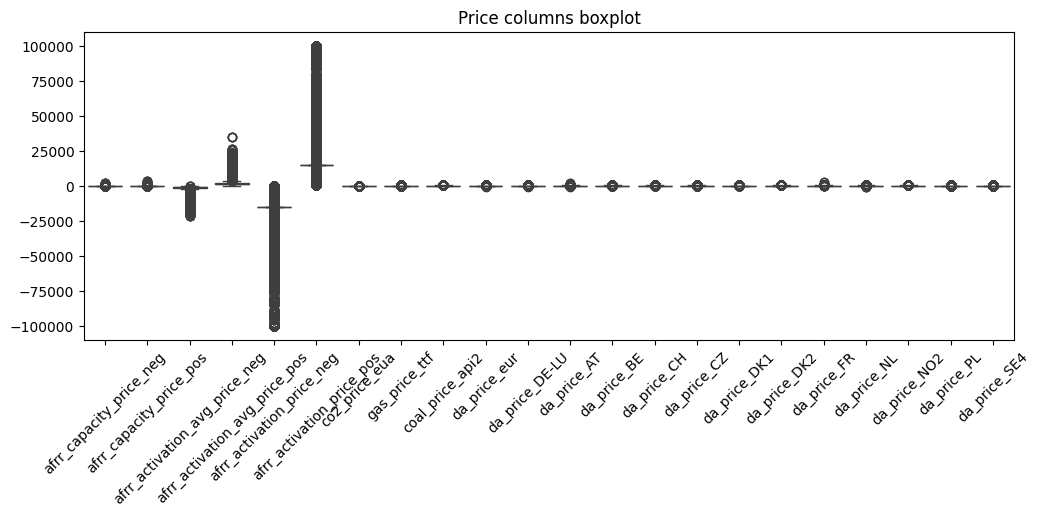

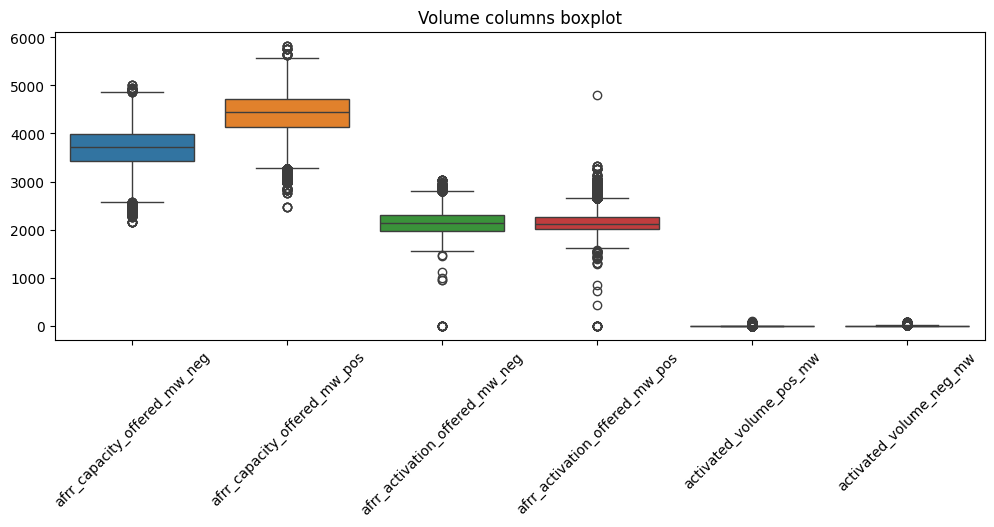

In [13]:
price_cols = []
vol_cols = []
for df in dfs.values():
    price_cols.extend([c for c in df.columns if 'price' in c.lower()])
    vol_cols.extend([c for c in df.columns if ('mw' in c.lower() or 'mwh' in c.lower()) and 'price' not in c.lower()])
price_cols = list(dict.fromkeys(price_cols))
vol_cols = list(dict.fromkeys(vol_cols))

def concat_cols(cols):
    frames = []
    for f, df in dfs.items():
        available = [c for c in cols if c in df.columns]
        if available:
            frames.append(df[available])
    if not frames:
        return None
    return pd.concat(frames, axis=0, ignore_index=True)

price_df = concat_cols(price_cols)
if price_df is not None and not price_df.empty:
    plt.figure(figsize=(12,4))
    sns.boxplot(data=price_df)
    plt.xticks(rotation=45)
    plt.title('Price columns boxplot')
    plt.show()
else:
    print('No price columns available for boxplot')

vol_df = concat_cols(vol_cols)
if vol_df is not None and not vol_df.empty:
    plt.figure(figsize=(12,4))
    sns.boxplot(data=vol_df)
    plt.xticks(rotation=45)
    plt.title('Volume columns boxplot')
    plt.show()
else:
    print('No volume columns available for boxplot')


## Merge readiness & overlap

In [14]:
# recommend resampling (simple heuristic)
recommendations = {}
for fname, df in dfs.items():
    step = avg_step(df)
    if pd.isna(step):
        rec = 'unknown cadence; inspect manually'
    elif step <= pd.Timedelta(minutes=15):
        rec = '<=15m; downsample to 1H with mean/sum'
    elif step <= pd.Timedelta(hours=1):
        rec = 'hourly; ready to merge'
    else:
        rec = 'daily; ffill to 1H before merge'
    recommendations[fname] = rec
pd.DataFrame.from_dict(recommendations, orient='index', columns=['resampling_reco'])


,resampling_reco
regelleistung.parquet,<=15m; downsample to 1H with mean/sum
co2_price.parquet,daily; ffill to 1H before merge
commodities.parquet,hourly; ready to merge
smard.parquet,hourly; ready to merge
netztransparenz.parquet,hourly; ready to merge
day_ahead_prices.parquet,hourly; ready to merge
entsoe.parquet,<=15m; downsample to 1H with mean/sum


In [15]:
# intersection of coverage
min_start = max(df['timestamp'].min() for df in dfs.values())
max_end = min(df['timestamp'].max() for df in dfs.values())
intersection_hours = int(((max_end - min_start).total_seconds())/3600) if max_end>min_start else 0
print('Intersection window:', min_start, 'to', max_end, '-> hours:', intersection_hours)


Intersection window: 2022-01-04 00:00:00+00:00 to 2025-12-30 00:00:00+00:00 -> hours: 34944


## Chronological split plan (train/val/test)
- Sort by `timestamp_utc` and avoid shuffling.
- Start with a 70/15/15 split (train/val/test) and adjust if the test window is too short.
- If using rolling features, insert a leakage gap (e.g., 24–168 hours) between splits.
- Use `energy_trading.features.splits.chronological_split` to generate the slices.

## Audit summary (run 2026-01-26)
- **Coverage overlap:** all 7 files now overlap from **2022-01-04 00:00 UTC** to **2025-12-30 00:00 UTC**.
- **Cadence:** 15-min (`regelleistung`, `entsoe`), hourly (`smard`, `commodities`, `day_ahead_prices`, `netztransparenz`), daily (`co2_price`).
- **Missingness hot-spots:** `entsoe` cross-border flow columns remain very sparse (about 79–97% NA; e.g., `flow_export_SE4` 96.6%); `day_ahead_prices` has 15.1% NA in `da_price_NO2`; `netztransparenz` has ~8.4% NA in `activated_volume_*_mw` and ~6.3% NA in `NRV_balance`/`nrv_imbalance`; `commodities` has about 1.6–1.9% NA in gas/coal/CO2; `smard` forecast columns are about 0.009% NA.
- **Duplicates:** 0 duplicate timestamps across all files.
- **Rule-based outliers:** `regelleistung` aFRR activation price series have large counts outside [-500, 3000]; `day_ahead_prices` spikes in `da_price_NO2` and `da_price_BE`; `netztransparenz` has negative `NRV_balance`/`nrv_imbalance` values (15,770) and some `reBAP_shortage_surplus` values outside [-500, 3000] (107); `commodities` shows hundreds of non-positive values in gas/coal/CO2 series.